In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Load the dataset
data = pd.read_csv("ipl.csv")

# Display the first few rows of the dataset
print(data.head())

# Check the data types and null values
print(data.info())

# Summary statistics
print(data.describe())


   Sl.NO.   PLAYER NAME  AGE COUNTRY  TEAM PLAYING ROLE  T-RUNS  T-WKTS  \
0       1   Abdulla, YA    2      SA  KXIP   Allrounder       0       0   
1       2  Abdur Razzak    2     BAN   RCB       Bowler     214      18   
2       3   Agarkar, AB    2     IND   KKR       Bowler     571      58   
3       4     Ashwin, R    1     IND   CSK       Bowler     284      31   
4       5  Badrinath, S    2     IND   CSK      Batsman      63       0   

   ODI-RUNS-S  ODI-SR-B  ...    SR-B  SIXERS  RUNS-C  WKTS  AVE-BL   ECON  \
0           0      0.00  ...    0.00       0     307    15   20.47   8.90   
1         657     71.41  ...    0.00       0      29     0    0.00  14.50   
2        1269     80.62  ...  121.01       5    1059    29   36.52   8.81   
3         241     84.56  ...   76.32       0    1125    49   22.96   6.23   
4          79     45.93  ...  120.71      28       0     0    0.00   0.00   

   SR-BL  AUCTION YEAR  BASE PRICE  SOLD PRICE  
0  13.93          2009       50000   

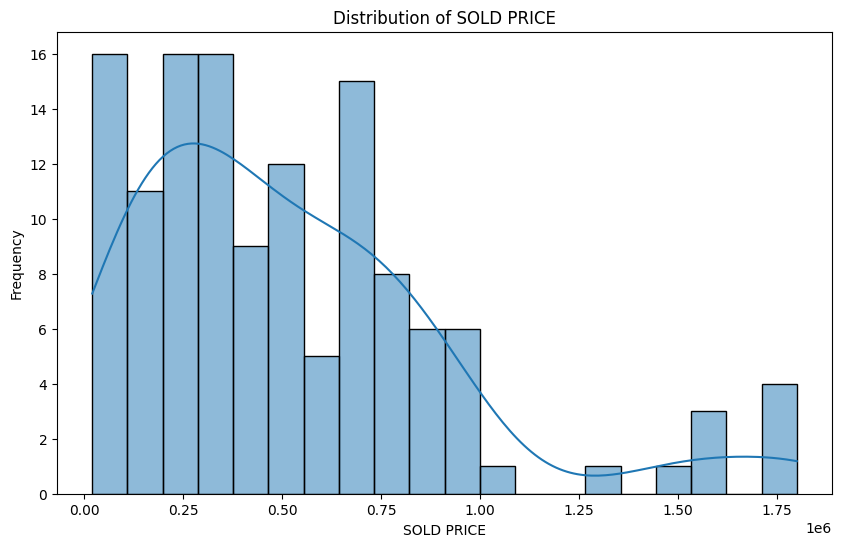

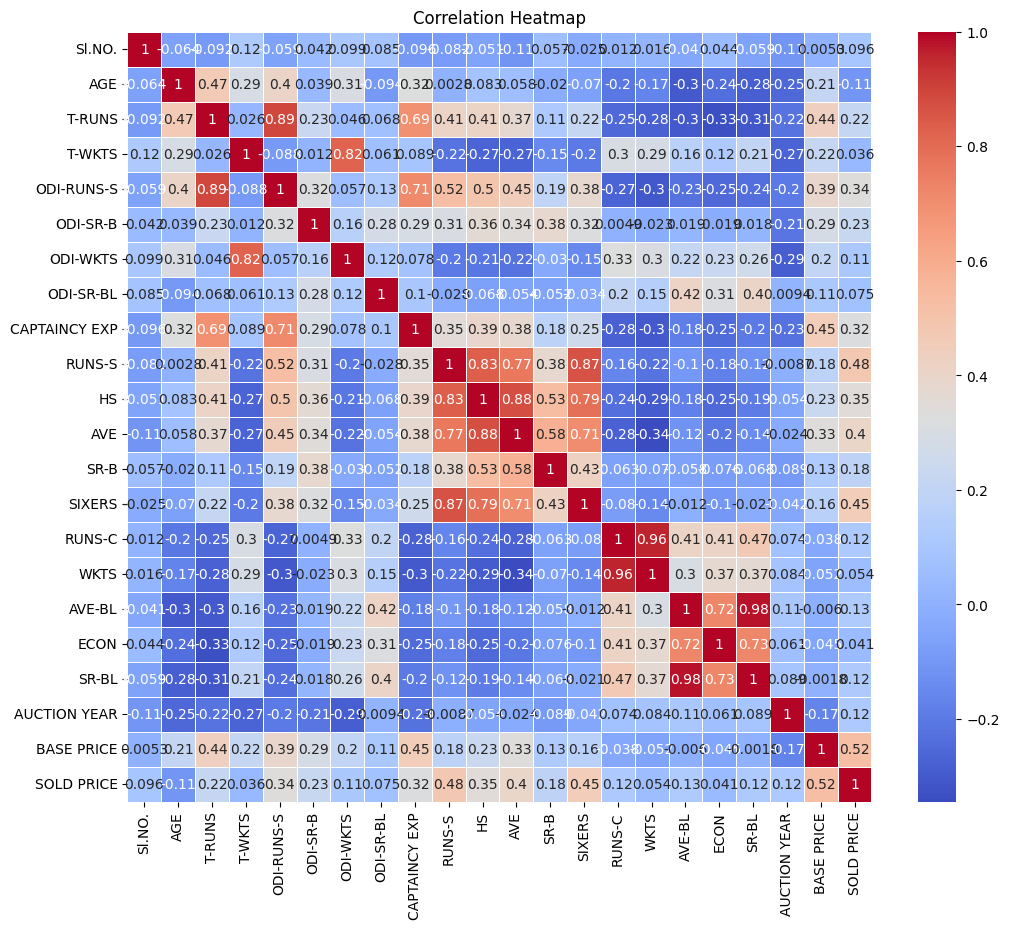

In [ ]:
# Distribution of the target variable 'SOLD PRICE'
plt.figure(figsize=(10, 6))
sns.histplot(data['SOLD PRICE'], bins=20, kde=True)
plt.title('Distribution of SOLD PRICE')
plt.xlabel('SOLD PRICE')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap
correlation_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()


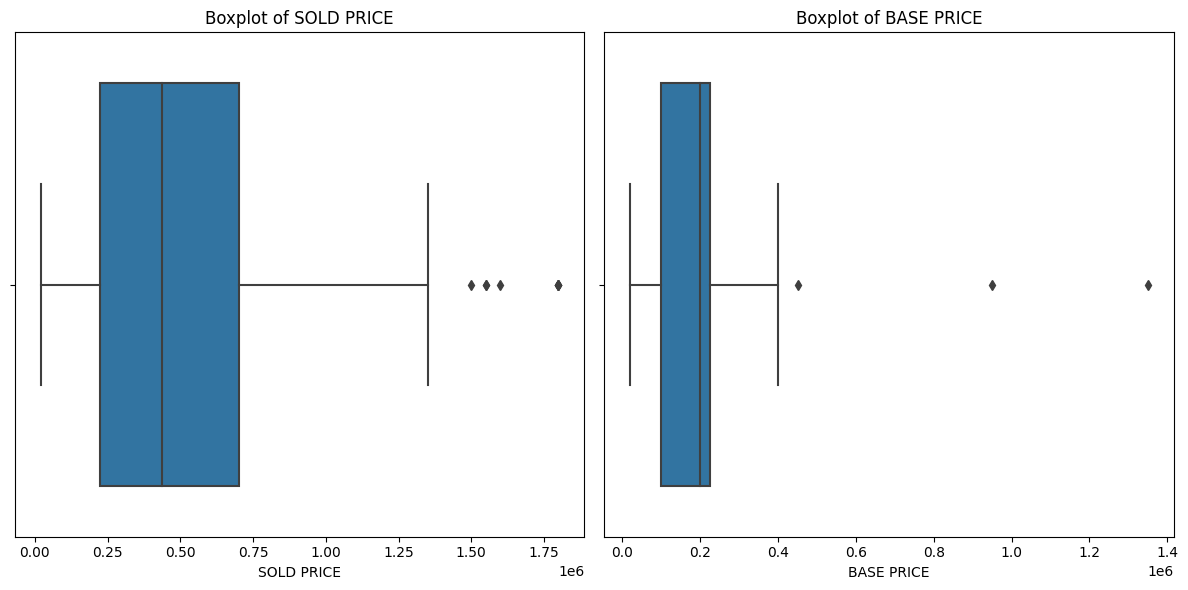

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=data['SOLD PRICE'])
plt.title('Boxplot of SOLD PRICE')

plt.subplot(1, 2, 2)
sns.boxplot(x=data['BASE PRICE'])
plt.title('Boxplot of BASE PRICE')

plt.tight_layout()
plt.show()


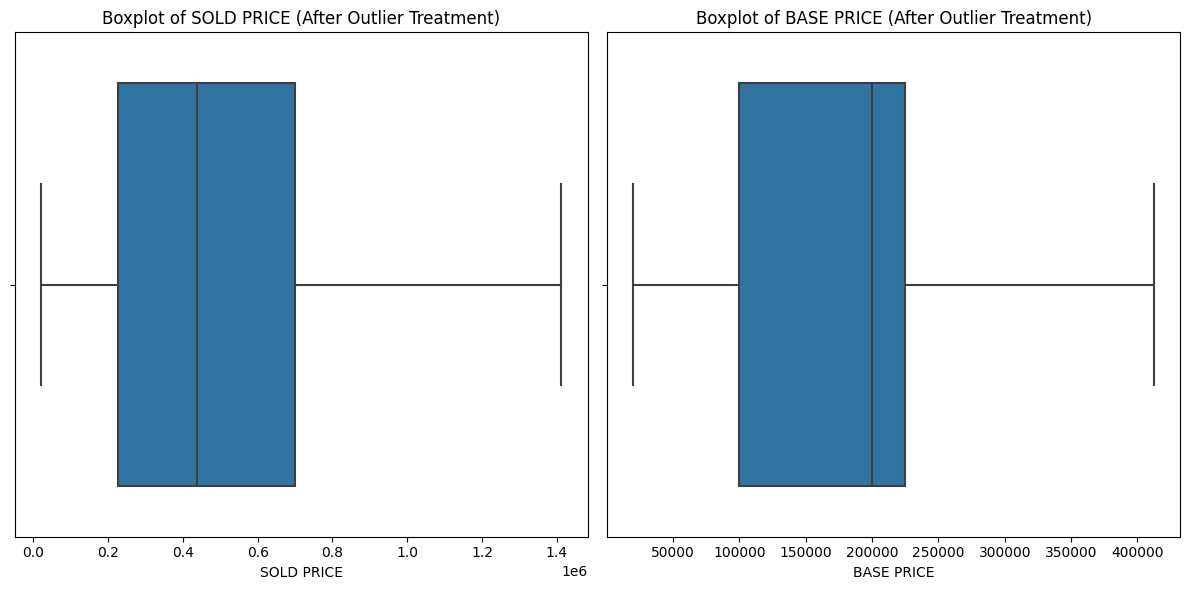

In [ ]:
# Define a function to handle outliers using capping
def handle_outliers(column, threshold):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - threshold * iqr
    upper_bound = q3 + threshold * iqr
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])

# Apply outlier treatment to 'SOLD PRICE' and 'BASE PRICE'
outlier_threshold = 1.5
handle_outliers('SOLD PRICE', outlier_threshold)
handle_outliers('BASE PRICE', outlier_threshold)

# Visualize the boxplots after outlier treatment
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=data['SOLD PRICE'])
plt.title('Boxplot of SOLD PRICE (After Outlier Treatment)')

plt.subplot(1, 2, 2)
sns.boxplot(x=data['BASE PRICE'])
plt.title('Boxplot of BASE PRICE (After Outlier Treatment)')

plt.tight_layout()
plt.show()


In [ ]:
# Transform character variables to numeric using one-hot encoding
data_encoded = pd.get_dummies(data, columns=['COUNTRY', 'TEAM', 'PLAYING ROLE'], drop_first=True)


In [ ]:
# Split data into features (X) and target variable (y)
X = data_encoded.drop(['SOLD PRICE', 'PLAYER NAME'], axis=1)  # Exclude 'PLAYER NAME' column and target variable
y = data_encoded['SOLD PRICE']

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict the auction price on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Mean Squared Error (MSE): 136807697888.82
R-squared (R2): -0.06


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler

# Feature selection
selector = SelectKBest(score_func=f_regression, k=10)  # Select top 10 features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)


In [ ]:
# Train the linear regression model on selected and scaled features
model.fit(X_train_scaled, y_train)

# Predict the auction price on the scaled test set
y_pred_scaled = model.predict(X_test_scaled)

# Evaluate the model on the scaled test set
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f"Scaled Mean Squared Error (MSE): {mse_scaled:.2f}")
print(f"Scaled R-squared (R2): {r2_scaled:.2f}")


Scaled Mean Squared Error (MSE): 81353900519.41
Scaled R-squared (R2): 0.37


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create and train a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict the auction price on the scaled test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the Random Forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest R-squared (R2): {r2_rf:.2f}")


Random Forest Mean Squared Error (MSE): 81367415566.03
Random Forest R-squared (R2): 0.37


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Create and train a Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Predict the auction price on the scaled test set using the Gradient Boosting model
y_pred_gb = gb_model.predict(X_test_scaled)

# Evaluate the Gradient Boosting model
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting Mean Squared Error (MSE): {mse_gb:.2f}")
print(f"Gradient Boosting R-squared (R2): {r2_gb:.2f}")


Gradient Boosting Mean Squared Error (MSE): 99104990846.94
Gradient Boosting R-squared (R2): 0.23


In [ ]:
from xgboost import XGBRegressor

# Create and train an XGBoost Regressor model
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Predict the auction price on the scaled test set using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate the XGBoost model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost R-squared (R2): {r2_xgb:.2f}")


XGBoost Mean Squared Error (MSE): 111319619709.72
XGBoost R-squared (R2): 0.13
